In [2]:
import pandas as pd 

In [3]:
df = pd.read_csv(
    "../data/raw/olid-training-v1.tsv"
)

In [5]:
df.head()
df.info()
df.shape
df.columns

<class 'pandas.DataFrame'>
RangeIndex: 13240 entries, 0 to 13239
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   id             13240 non-null  int64
 1   tweet          13240 non-null  str  
 2   cleaned_tweet  13170 non-null  str  
 3   subtask_a      13240 non-null  str  
 4   subtask_b      4400 non-null   str  
 5   subtask_c      3876 non-null   str  
dtypes: int64(1), str(5)
memory usage: 620.8 KB


Index(['id', 'tweet', 'cleaned_tweet', 'subtask_a', 'subtask_b', 'subtask_c'], dtype='str')

In [6]:
df["subtask_a"].value_counts()

subtask_a
NOT    8840
OFF    4400
Name: count, dtype: int64

In [7]:
df["subtask_a"].value_counts(normalize=True) * 100

subtask_a
NOT    66.767372
OFF    33.232628
Name: proportion, dtype: float64

In [8]:
df.isnull().sum()


id                  0
tweet               0
cleaned_tweet      70
subtask_a           0
subtask_b        8840
subtask_c        9364
dtype: int64

In [9]:
df["tweet"].duplicated().sum()

np.int64(33)

In [10]:
df[["tweet", "subtask_a"]].sample(20, random_state=42)

,tweet,subtask_a
12387,@USER @USER Why is John Kerry running his mout...,NOT
385,@USER @USER Gun control anyone? #DisarmHate,NOT
4896,@USER What manga you reading?,NOT
3971,@USER You are right. Victoria is on the revers...,NOT
10394,@USER @USER Thank you @USER . America is respe...,NOT
12889,@USER They are Antifa democrats disguised as G...,NOT
4504,@USER @USER @USER How do you come up with all ...,OFF
3268,@USER bitch my life was flashing before my eyes,OFF
2439,@USER Lmao what a joke he is.,NOT
4688,@USER @USER @USER @USER @USER Looking forward ...,NOT


In [11]:
df["subtask_b"].value_counts(dropna=False)

subtask_b
NaN    8840
TIN    3876
UNT     524
Name: count, dtype: int64

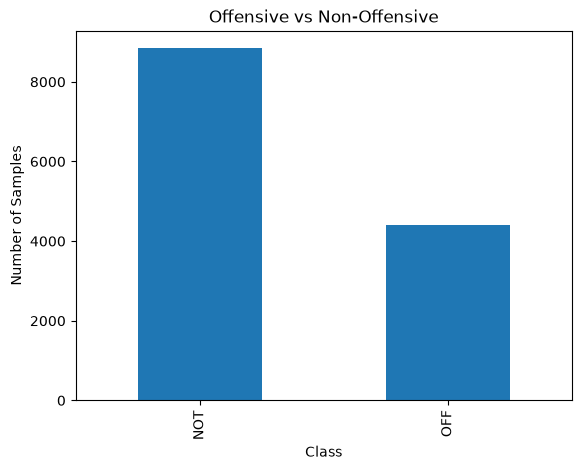

In [12]:
import matplotlib.pyplot as plt

df["subtask_a"].value_counts().plot(kind="bar")

plt.title("Offensive vs Non-Offensive")
plt.xlabel("Class")
plt.ylabel("Number of Samples")
plt.show()

In [13]:
df[["tweet", "subtask_a"]].isnull().sum()

tweet        0
subtask_a    0
dtype: int64

In [14]:
df.shape


(13240, 6)

In [15]:
df = df.drop_duplicates(subset="tweet")

In [16]:
df.shape

(13207, 6)

In [17]:
df_model = df[["tweet", "subtask_a"]].copy()

In [18]:
df_model.head()

,tweet,subtask_a
0,@USER She should ask a few native Americans wh...,OFF
1,@USER @USER Go home you’re drunk!!! @USER #MAG...,OFF
2,Amazon is investigating Chinese employees who ...,NOT
3,"@USER Someone should'veTaken"" this piece of sh...",OFF
4,@USER @USER Obama wanted liberals &amp; illega...,NOT


In [19]:
df_model.shape

(13207, 2)

In [20]:
X = df_model["tweet"]
y = df_model["subtask_a"]

In [21]:
print(X.shape)
print(y.shape)

(13207,)
(13207,)


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y #ensures that offensive and non off twees ratio is same in both training and testing 
)

In [23]:
print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 10565
Testing samples: 2642


In [24]:
print("Training samples:", len(y_train))
print("Testing samples:", len(y_test))

Training samples: 10565
Testing samples: 2642


In [31]:
print("\nTraining distribution:")
print(y_train.value_counts(normalize=True) * 100)

print("\nTesting distribution:")
print(y_test.value_counts(normalize=True) * 100)


Training distribution:
subtask_a
NOT    66.748699
OFF    33.251301
Name: proportion, dtype: float64

Testing distribution:
subtask_a
NOT    66.72975
OFF    33.27025
Name: proportion, dtype: float64


In [26]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer()

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("Training shape:", X_train_tfidf.shape)
print("Testing shape:", X_test_tfidf.shape)
print("Number of features:", len(tfidf.vocabulary_))

Training shape: (10565, 16969)
Testing shape: (2642, 16969)
Number of features: 16969


In [27]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(max_iter=1000)

lr_model.fit(X_train_tfidf, y_train)

y_pred = lr_model.predict(X_test_tfidf)

print(y_pred[:20])

['NOT' 'NOT' 'NOT' 'NOT' 'NOT' 'OFF' 'NOT' 'OFF' 'NOT' 'NOT' 'NOT' 'NOT'
 'NOT' 'NOT' 'NOT' 'NOT' 'NOT' 'NOT' 'NOT' 'NOT']


In [28]:
from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         NOT       0.75      0.95      0.84      1763
         OFF       0.78      0.38      0.51       879

    accuracy                           0.76      2642
   macro avg       0.77      0.66      0.67      2642
weighted avg       0.76      0.76      0.73      2642



In [29]:
print(confusion_matrix(y_test, y_pred))

[[1668   95]
 [ 545  334]]
